## **DSAI544 - Computer Vision with Machine Learning**

> ## **Assignment 2**


>**Student's Name**: Yiğit Ateş

* The full assignment is worth 15 points in total.
* Write your answers within the correct exercise sections.
* Submit your .ipynb file to Moodle before the due time.
* Files should be named in the following format: DSAI544 Assignment 2 Name Surname
* Your submission must contain your output cells. Those will be necessary for the grading process.

### **Exercise 1: Transformer Based Architecture**⚡
*5 points*

Below is the model definition for a Transformer Network with a Convolutional Patch Embedding layer. Your task is to optimize the network architecture below to improve the model performance. The minimum criteria for success is %75 validation accuracy. Share your training setup including your architecture and any other modifications you have made after the assignment deadline in the Moodle forum. Three students who have the highest accuracy among you will get 2 extra points.

You are free to use other components like MaxPool2d, Dropout, and ReLU from torch.nn library. Please remember the architectural innovations and regularization methods mentioned in the class and try to emulate them here (for instance at the input side of the model you can use known CNN baselines as feature extractor by reimplementing them). You can also change augmentation, learning rate schedulers, optimization methods, positional encoding method and number of attention-head as you like. Don't use predefined models right away but you can reimplement them yourselves.

You will find an implementation from our class for Attention Head and Attention Blocks. Also PS-5&6 might give an insight about swin based structures. **Feel free to improve this implementation and integrate other components**. Keep in mind that CIFAR10 is not a very large dataset so optimizing transformers may prove to be more difficult which is generally not true for larger datasets. Try to restrict the number of parameters that you have in order to get a good generalization performance.

In [1]:
print("test")

test


In [2]:
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

In [3]:
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

cifar10 = torchvision.datasets.CIFAR10(root='./data', download=True, train=True, transform=transform)
cifar10_test = torchvision.datasets.CIFAR10(root='./data', download=True, train=False, transform=test_transform)

batch_size = 128
dataloader = DataLoader(cifar10, batch_size=batch_size, shuffle=True, num_workers=2)
dataloader_test = DataLoader(cifar10_test, batch_size=batch_size, shuffle=False, num_workers=2)

In [4]:
class Head(nn.Module):
  def __init__(self, head_size, embed_dim=None):
    super().__init__()
    self.head_size=head_size
    embed_dim = head_size if embed_dim == None else embed_dim
    self.key = nn.Linear(embed_dim, head_size, bias=False)
    self.query = nn.Linear(embed_dim, head_size, bias=False)
    self.value = nn.Linear(embed_dim, head_size, bias=False)
    self.dropout = nn.Dropout(0.1)

  def forward(self, x):
      k = self.key(x)
      q = self.query(x)
      v = self.value(x)
      weight = q @ k.transpose(-2,-1) * self.head_size**-0.5
      weight = F.softmax(weight, dim=-1)
      output = weight @ v
      return output

class MultiheadAttention(nn.Module):
  def __init__(self,embed_dim, num_heads):
    super().__init__()
    head_size = embed_dim// num_heads
    self.heads = nn.ModuleList([Head(head_size, embed_dim=embed_dim) for _ in range(num_heads)])
    self.proj = nn.Linear(embed_dim, embed_dim)

  def forward(self, x):
    output = torch.cat([h(x) for h in self.heads], dim=2)
    output =  self.proj(output)
    return output

class FeedForward(nn.Module):
  def __init__(self, embed_dim):
    super().__init__()
    self.net = nn.Sequential(
      nn.Linear(embed_dim, 4 * embed_dim),
      nn.GELU(),
      nn.Dropout(0.1),
      nn.Linear(4 * embed_dim, embed_dim),
      nn.Dropout(0.1)
    )

  def forward(self, x):
    return self.net(x)

class Block(nn.Module):
  def __init__(self, embed_dim, num_heads):
    super().__init__()
    self.sa = MultiheadAttention(embed_dim, num_heads)
    self.ffwd = FeedForward(embed_dim)
    self.ln1 = nn.LayerNorm(embed_dim)
    self.ln2 = nn.LayerNorm(embed_dim)

  def forward(self,x):
    x = x + self.sa(self.ln1(x))
    x = x + self.ffwd(self.ln2(x))
    return x

class Flatten_Spatial(nn.Module):
  def __init__(self, grid_size, embed_dim):
    super().__init__()
    self.grid_size = grid_size
    self.embed_dim = embed_dim
    self.pos_embed = self.build_2d_sincos_position_embedding(self.grid_size, self.embed_dim)

  def build_2d_sincos_position_embedding(self, grid_size, embed_dim,temperature=10000.):
        h, w = grid_size
        grid_w = torch.arange(w, dtype=torch.float32)
        grid_h = torch.arange(h, dtype=torch.float32)
        grid_w, grid_h = torch.meshgrid(grid_w, grid_h)
        assert embed_dim % 4 == 0, 'Embed dimension must be divisible by 4 for 2D sin-cos position embedding'
        pos_dim = embed_dim // 4
        omega = torch.arange(pos_dim, dtype=torch.float32) / pos_dim
        omega = 1. / (temperature**omega)
        out_w = torch.einsum('m,d->md', [grid_w.flatten(), omega])
        out_h = torch.einsum('m,d->md', [grid_h.flatten(), omega])
        pos_embed =  nn.Parameter(torch.cat([torch.sin(out_w), torch.cos(out_w), torch.sin(out_h), torch.cos(out_h)], dim=1)[None, :, :])
        pos_embed.requires_grad = False
        return pos_embed

  def forward(self, x):
    B,C,H,W = x.shape
    x = x.permute(0,2,3,1).reshape(B,H*W,self.embed_dim)
    x = x + self.pos_embed
    return x

class GlobalAveragePooling(nn.Module):
    def forward(self, x):
        return x.mean(dim=1)

In [5]:
# You can define your own model
model = nn.Sequential(
    nn.Conv2d(3, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.GELU(),
    nn.Conv2d(64, 128, 3, stride=1, padding=1), nn.BatchNorm2d(128), nn.GELU(),
    nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.BatchNorm2d(256), nn.GELU(),
    Flatten_Spatial(grid_size=(8, 8), embed_dim=256),
    Block(256, 8),
    Block(256, 8),
    Block(256, 8),
    Block(256, 8),
    Block(256, 8),
    Block(256, 8),
    GlobalAveragePooling(),
    nn.LayerNorm(256),
    nn.Linear(256, 10)
)

device = 'mps' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
print(model)

optim = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=100, eta_min=1e-6)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): GELU(approximate='none')
  (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): GELU(approximate='none')
  (9): Flatten_Spatial()
  (10): Block(
    (sa): MultiheadAttention(
      (heads): ModuleList(
        (0-7): 8 x Head(
          (key): Linear(in_features=256, out_features=32, bias=False)
          (query): Linear(in_features=256, out_features=32, bias=False)
          (value): Linear(in_features=256, out_features=32, bias=False)
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
   

/Users/yigitates/Desktop/notebooks/.venv/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4319.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [6]:
i = 0
losses = []
steps = []
losses_t = []

In [7]:
import math

num_epochs = 100

for epoch in range(num_epochs):
    print("======== epoch:", epoch)
    for batch in dataloader:
        i += 1
        x = batch[0].to('mps')
        y = batch[1].to('mps')
        model = model.to('mps')
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        optim.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()
        losses.append(loss.item())
        losses_t.append(loss.detach())
        steps.append(i)
        if i % 1000 == 0:
            print(f"step {i}, loss={loss.item():.4f}, lr={optim.param_groups[0]['lr']:.6f}")

    scheduler.step()

======== epoch: 0


======== epoch: 1
======== epoch: 2
step 1000, loss=1.2815, lr=0.000999
======== epoch: 3
======== epoch: 4
======== epoch: 5
step 2000, loss=0.6840, lr=0.000994
======== epoch: 6
======== epoch: 7
step 3000, loss=0.5680, lr=0.000988


KeyboardInterrupt: 

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optim.state_dict()
}, 'checkpoint.pth')

In [ ]:
plt.plot(steps, losses)

In [ ]:
# !Do not make major change in this cell

total_correct = 0
total_predictions = 0

# Loop over training dataset
for x_batch, y_batch in dataloader:
    logits = model(x_batch.to("cuda")) # Forward pass on the mini-batch
    loss = F.cross_entropy(logits.cpu(), y_batch) # Compute loss

    # Calculate predictions for the batch
    pred_labels = torch.max(logits, dim=1).indices

    # Update total correct predictions and total predictions
    total_correct += (y_batch == pred_labels.cpu()).sum().item()
    total_predictions += y_batch.size(0)

# Calculate overall accuracy
overall_accuracy = total_correct / total_predictions
print(f"Training Accuracy: {overall_accuracy}")

In [ ]:
# !Do not make major change in this cell

total_correct = 0
total_predictions = 0

# Loop over testing dataset
for x_batch, y_batch in dataloader_test:
    logits = model(x_batch.to("cuda")) # Forward pass on the mini-batch
    loss = F.cross_entropy(logits.cpu(), y_batch) # Compute loss

    # Calculate predictions for the batch
    pred_labels = torch.max(logits, dim=1).indices

    # Update total correct predictions and total predictions
    total_correct += (y_batch == pred_labels.cpu()).sum().item()
    total_predictions += y_batch.size(0)

# Calculate overall accuracy
overall_accuracy = total_correct / total_predictions
print(f"Testting Accuracy: {overall_accuracy}")


## **Exercise 2: Detecting and Segmenting Raccoons 🦝**
*10 points*

#### **Step 1**

In this first step, you will set up the environment. You need to import the necessary libraries for this project, such as autodistill-grounded-sam, supervision, ultralytics, roboflow, and PyTorch with torchvision. Make sure to install them using pip. This ensures that we have all the tools we need to work with GroundedSAM and YOLO for image analysis and model training. The code is already given. Run & proceed to the next step.

**Working Package Versions**

If the code doesn't work in your environment, try installing the packages with respect to these versions, then try again it will probably work.


*   `autodistill: 0.1.29`
*   `autodistill_grounded_sam: 0.1.2`
*   `roboflow: 1.2.11`
*   `ultralytics: 8.3.235`





In [ ]:
!pip install autodistill-grounded-sam
!pip install supervision
!pip install ultralytics
!pip install roboflow
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install ipywidgets

#### **Step 2**

Now, import the specific components that you will use from the installed libraries. You will be utilizing GroundedSAM for object detection and segmentation, CaptionOntology for defining object categories, plotting tools from autodistill, and OpenCV for basic image operations. Importing these modules makes them readily available for use in your code. The code is already given. Run & proceed to the next step.

In [ ]:
from autodistill_grounded_sam import GroundedSAM
from autodistill.detection import CaptionOntology
from autodistill.utils import plot
import cv2

In [ ]:
from autodistill.detection.detection_base_model import roboflow
import autodistill
import autodistill_grounded_sam
import ultralytics

print("autodistill:", autodistill.__version__)
print("autodistill_grounded_sam:", autodistill_grounded_sam.__version__)
print("roboflow:", roboflow.__version__)
print("ultralytics:", ultralytics.__version__)

#### **Step 3**

Before you can start processing images, you need to prepare the dataset. Upload the dataset to Google Colab (if you are using Colab). This code block will focus on extracting image data from the zip file named 'images.zip'. First, define the path to the zip file and the directory where images should be extracted. Then, use the zip file library to extract the contents of the zip file into the specified directory. Unzip your files.

**You can download the dataset from this drive** [**link**](https://drive.google.com/file/d/1a6ebsACZXugcI6oWr6wo4GD2vcGbKB19/view?usp=sharing)

In [ ]:
import zipfile
import os

# I loaded the zip file to my Colab workspace manually
zip_file_path = '/content/images.zip'
output_dir = '/content/images'

os.makedirs(output_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"Files extracted")



#### **Step 4**

Here, initialize the GroundedSAM model (name it as base_model) using a specific ontology. The ontology, defined using CaptionOntology, specifies the categories of objects you are interested in. In this case, you are only focusing on detecting and segmenting 'raccoons.' Creating this base model sets the foundation for object recognition in your images. You will use this model to label your dataset.
Your code will look like this, fill the stars:
```
base_model = GroundedSAM(
    ontology=CaptionOntology(
        {
            "*******": "*******"
        }
    )
)
```





In [ ]:
base_model = GroundedSAM(
    ontology=CaptionOntology(
        {
            "raccoon": "raccoon"
        }
    )
)

#### **Step 5**

Now, test the GroundedSAM model on a single image. Choose a random image from the dataset by hand, load it, perform inference using the .predict() method of `base_model`, and then visualize the results.

Use the plot function which will help you to see the detected objects, their bounding boxes, and segmentation masks overlaid on the original image. This gives you a visual confirmation of the model's performance.

In [ ]:
import supervision as sv

image_path = '/content/images/images/rac (103).jpg'


# annotators for masks and boxes
mask_annotator = sv.MaskAnnotator()
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

confirmation_image = cv2.imread(image_path)

detections = base_model.predict(confirmation_image)
print("detections:",detections)

labels = [
    f"{classes[class_id]} {conf:.2f}"
    for class_id, conf in zip(detections.class_id, detections.confidence)
]

annotated_frame = box_annotator.annotate(
    scene=confirmation_image.copy(),
    detections=detections
)

annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=detections,
    labels=labels
)

sv.plot_image(annotated_frame, size=(8, 8))


#### **Step 6**

To train a more specific model using YOLO, we need labeled data. Use the GroundedSAM model (named as `base_model` in previous steps) to label images. It will use the predefined ontology to identify and label 'raccoons' in the dataset. The labeled data will be crucial for fine-tuning the YOLO model in the next steps. Use the .label() method of "base_model" you defined in step 4 with the correct path and extension parameters.

In [ ]:
images_path = '/content/images/images'
labels_path = '/content/labeled_data'

dataset = base_model.label(
    input_folder=images_path,
    extension='.jpg',
    output_folder=labels_path
)
print(f"Labeled data has been saved to: {labels_path}")

#### **Step 7**


Now over colab's UI, prepare a UI where you can view images with their labels. If the labeling is not successful, you will remove the image and its corresponding .txt labeling file. Iterate over the dataset and remove the unsuccessfully labeled ones. An example solution code for such UI is given below. Please note that it is natural to have a very different code as your solution as many things can vary (naming, design, paths, etc...).

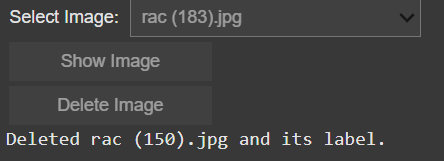


```
import os
import ipywidgets as widgets
from IPython.display import display, clear_output


# paths to dataset splits
base_dir = "/content/labeled_data"
splits = ["train", "valid"]


# Helper function to plot an image with detections
def plot_image_with_detections(image_path, base_model):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


    # help(base_model.predict)
    # setting threshold to 0.1
    base_model.box_threshold = 0.1
    base_model.text_threshold = 0.1
    print("box thresh:",base_model.box_threshold)
    print("text thresh:",base_model.text_threshold)
    detections = base_model.predict(image_path)

    mask_annotator = sv.MaskAnnotator()
    box_annotator = sv.BoxAnnotator()

    annotated_image = mask_annotator.annotate(scene=image.copy(), detections=detections)
    annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)

    # draw class labels manually, updated supervision does not do it
    for box, class_id, confidence in zip(detections.xyxy, detections.class_id, detections.confidence):
        # bbox coordinates
        x1, y1, x2, y2 = map(int, box)

        # labels
        label = f"{classes[class_id]} {confidence:.2f}"

        cv2.rectangle(annotated_image, (x1, y1 - 20), (x1 + len(label) * 10, y1), (0, 0, 0), -1)
        cv2.putText(annotated_image, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)


    sv.plot_image(annotated_image, size=(8, 8))


# get the list of images in the selected split
def get_image_list(split):
    images_dir = os.path.join(base_dir, split, "images")
    return [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]


def show_image_selection_ui(base_model):
    # dropdown to select the dataset split
    split_selector = widgets.Dropdown(
        options=splits,
        description='Select Split:',
        disabled=False
    )

    # dropdown to select an image
    image_selector = widgets.Dropdown(
        options=[],
        description='Select Image:',
        disabled=False
    )

    # buttons
    show_button = widgets.Button(description="Show Image", button_style='success')
    delete_button = widgets.Button(description="Delete Image", button_style='danger')
    output = widgets.Output()


    def update_image_list(change):
        split = split_selector.value
        image_list = get_image_list(split)
        image_selector.options = image_list


    def show_image(change):
        with output:
            clear_output(wait=True)
            split = split_selector.value
            image_path = os.path.join(base_dir, split, "images", image_selector.value)
            plot_image_with_detections(image_path, base_model)


    def delete_image(change):
        with output:
            clear_output(wait=True)
            split = split_selector.value
            image_path = os.path.join(base_dir, split, "images", image_selector.value)
            label_path = os.path.join(base_dir, split, "labels", os.path.splitext(image_selector.value)[0] + ".txt")

            if os.path.exists(image_path):
                os.remove(image_path)
            if os.path.exists(label_path):
                os.remove(label_path)

            # update the dropdown options after deletion
            image_selector.options = get_image_list(split)
            print(f"Deleted {os.path.basename(image_path)} and its label.")


    split_selector.observe(update_image_list, names='value')
    show_button.on_click(show_image)
    delete_button.on_click(delete_image)

    # display UI
    display(widgets.VBox([split_selector, image_selector, show_button, delete_button, output]))
    update_image_list(None)

show_image_selection_ui(base_model)

```



In [ ]:
import os
import ipywidgets as widgets
from IPython.display import display, clear_output


# paths to dataset splits
base_dir = "/content/labeled_data"
splits = ["train", "valid"]


# Helper function to plot an image with detections
def plot_image_with_detections(image_path, base_model):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


    # help(base_model.predict)
    # setting threshold to 0.1
    base_model.box_threshold = 0.1
    base_model.text_threshold = 0.1
    print("box thresh:",base_model.box_threshold)
    print("text thresh:",base_model.text_threshold)
    detections = base_model.predict(image_path)

    mask_annotator = sv.MaskAnnotator()
    box_annotator = sv.BoxAnnotator()

    annotated_image = mask_annotator.annotate(scene=image.copy(), detections=detections)
    annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)

    # draw class labels manually, updated supervision does not do it
    for box, class_id, confidence in zip(detections.xyxy, detections.class_id, detections.confidence):
        # bbox coordinates
        x1, y1, x2, y2 = map(int, box)

        # labels
        label = f"{classes[class_id]} {confidence:.2f}"

        cv2.rectangle(annotated_image, (x1, y1 - 20), (x1 + len(label) * 10, y1), (0, 0, 0), -1)
        cv2.putText(annotated_image, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)


    sv.plot_image(annotated_image, size=(8, 8))


# get the list of images in the selected split
def get_image_list(split):
    images_dir = os.path.join(base_dir, split, "images")
    return [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]


def show_image_selection_ui(base_model):
    # dropdown to select the dataset split
    split_selector = widgets.Dropdown(
        options=splits,
        description='Select Split:',
        disabled=False
    )

    # dropdown to select an image
    image_selector = widgets.Dropdown(
        options=[],
        description='Select Image:',
        disabled=False
    )

    # buttons
    show_button = widgets.Button(description="Show Image", button_style='success')
    delete_button = widgets.Button(description="Delete Image", button_style='danger')
    output = widgets.Output()


    def update_image_list(change):
        split = split_selector.value
        image_list = get_image_list(split)
        image_selector.options = image_list


    def show_image(change):
        with output:
            clear_output(wait=True)
            split = split_selector.value
            image_path = os.path.join(base_dir, split, "images", image_selector.value)
            plot_image_with_detections(image_path, base_model)


    def delete_image(change):
        with output:
            clear_output(wait=True)
            split = split_selector.value
            image_path = os.path.join(base_dir, split, "images", image_selector.value)
            label_path = os.path.join(base_dir, split, "labels", os.path.splitext(image_selector.value)[0] + ".txt")

            if os.path.exists(image_path):
                os.remove(image_path)
            if os.path.exists(label_path):
                os.remove(label_path)

            # update the dropdown options after deletion
            image_selector.options = get_image_list(split)
            print(f"Deleted {os.path.basename(image_path)} and its label.")


    split_selector.observe(update_image_list, names='value')
    show_button.on_click(show_image)
    delete_button.on_click(delete_image)

    # display UI
    display(widgets.VBox([split_selector, image_selector, show_button, delete_button, output]))
    update_image_list(None)

show_image_selection_ui(base_model)

#### **Step 8**

Now leverage the power of YOLO for more robust object detection. Start by importing the YOLO from the ultralytics library. Then, load a pre-trained YOLO11n model. Name it `model_detect`.

Use:
`model_detect = YOLO("yolo11n.pt")`

Next, use the .train() method to fine-tune this model on the labeled data generated earlier. This process will involve feeding the model our labeled images and allowing it to learn and adjust its parameters for better performance. Pass the path to the .yaml file (ex.  `data="/content/images_labeled/data.yaml"`) inside the train function. Remember to specify training parameters. Set  `imgsz=416` and `name="yolo_detection"`.




In [ ]:
from ultralytics import YOLO

model_downstream = YOLO("yolo11n.pt")

data_yaml_path = "/content/labeled_data/data.yaml"

model_downstream.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=416,
    batch=16,
    name="yolo_detection",
    patience=20,
    device=0  # Use GPU
)

# save trained model
model_downstream.save("yolo_detection_trained.pt")

#### **Step 9**

Now, let's see the YOLO model in action on a new image! Load a test image, choose it by hand from the validation dataset and use the trained model to make prediction on it. The result will contain information about the detected object, including their bounding boxes and confidence scores.

Use the show method to display the results visually – this will overlay the detected objects on the test image, giving you a clear view of the model's detection capabilities.

In [ ]:
import matplotlib.pyplot as plt

# you can change your test image
test_image_path = "/content/labeled_data/valid/images/rac (144).jpg"

# Load best weights from training
model_trained = YOLO("runs/detect/yolo_detection/weights/best.pt")

# Run prediction
results = model_trained.predict(
    source=test_image_path,
    conf=0.25,  # Confidence threshold
    save=False,
    show=False
)

# Visualize results
results[0].show()

annotated_img = results[0].plot()
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Print detection info
for box in results[0].boxes:
    print(f"Class: {model_trained.names[int(box.cls)]}, Confidence: {box.conf.item():.2f}")

#### **Step 10**

For the detection model, output the "results.png" generated in /runs folder.

In [ ]:
from IPython.display import Image, display

results_path = "/content/runs/detect/yolo_detection/results.png"
display(Image(filename=results_path))

#### **Step 11**

Finally, to make your trained YOLO model usable in other environments or applications, you need to export it to a suitable format. The export method allows you to save the model in various formats like ONNX, Torchscript, or CoreML, depending on your needs.

In this exercise you will export your model in "onnx" format for future use. This ensures that your trained model is portable and can be integrated into different systems.

In [ ]:
model_downstream.export(format="onnx")

#### **Step 12**

Now do the last steps again with the segmentation model.
Start with the code below. Again, set `imgsz=416` and `name="yolo_segmentation"`.

Use:
`model_segment = YOLO("yolo11n-seg.pt")`

In [ ]:
model_segment = YOLO("yolo11n-seg.pt")

model_segment.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=416,
    batch=16,
    name="yolo_segmentation",
    patience=20,
    device=0
)

# Save trained model
model_segment.save("yolo_segmentation_trained.pt")

#### **Step 13**

Again, use the show method to display the results visually for the same image you choose in step 9 – this will overlay the detected objects with their segmentations on the test image, giving you a clear view of the model's segmentation capabilities.

In [ ]:
model_seg_trained = YOLO("runs/segment/yolo_segmentation/weights/best.pt")

results = model_seg_trained.predict(
    source=test_image_path,
    conf=0.25,
    save=False,
    show=False
)

if results[0].masks is not None:
    results[0].show()

    for i, mask in enumerate(results[0].masks.data):
        box = results[0].boxes[i]
        print(f"Object {i+1} - Class: {model_seg_trained.names[int(box.cls)]}, "
              f"Confidence: {box.conf.item():.2f}, Mask pixels: {mask.sum().item():.0f}")
else:
    print("No detections found.")

#### **Step 14**

For the segmentation model, output the "results.png" generated in the /runs folder.

In [ ]:
results_path = "/content/runs/segment/yolo_segmentation/results.png"
display(Image(filename=results_path))

#### **Step 15**

Export your segmentation model in "onnx" format.

In [ ]:
model_segment.export(format="onnx")

Congratulations! 🎉

Now you have successfully fine-tuned your detection and segmentation models. They are ready to use.